# 04 · Explore the processed data

In [2]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host=os.getenv("DATASET_POSTGRES_HOST", "dataset-postgres"),
    port=os.getenv("DATASET_POSTGRES_PORT", "5432"),
    dbname=os.getenv("DATASET_POSTGRES_DB", "heart_disease"),
    user=os.getenv("DATASET_POSTGRES_USER", "dataset_user"),
    password=os.getenv("DATASET_POSTGRES_PASSWORD", "dataset_pass"),
)
try:
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM heart_disease_processed")
        columns = [description.name for description in cur.description]
        df = pd.DataFrame(cur.fetchall(), columns=columns)
finally:
    conn.close()
if df.empty:
    raise ValueError("heart_disease_processed is empty; run notebook 02 first")
if "target" not in df.columns:
    raise ValueError("Expected a target column; rerun notebook 02")
print(f"Rows: {len(df):,} | features: {df.shape[1] - 1} | duplicate rows: {df.duplicated().sum():,}")
display(df.dtypes.rename("dtype").to_frame())
display(df.describe(include="all").T)


Rows: 297 | features: 13 | duplicate rows: 0


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


## Data quality and class balance

The processed table should have no null values because step 02 drops incomplete rows. Review the class balance to understand how representative accuracy may be.

,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


,rows
target,
0,160
1,137


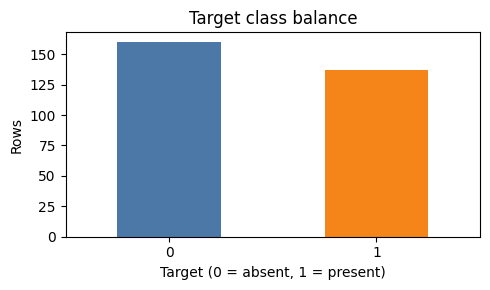

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.rename("missing_values").to_frame())
class_counts = df["target"].value_counts(dropna=False).sort_index()
display(class_counts.rename_axis("target").to_frame("rows"))
ax = class_counts.plot(kind="bar", color=["#4C78A8", "#F58518"], figsize=(5, 3))
ax.set(title="Target class balance", xlabel="Target (0 = absent, 1 = present)", ylabel="Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Feature distributions

Quick histograms for three clinical features. Check ranges, concentrated values, and possible outliers before training.

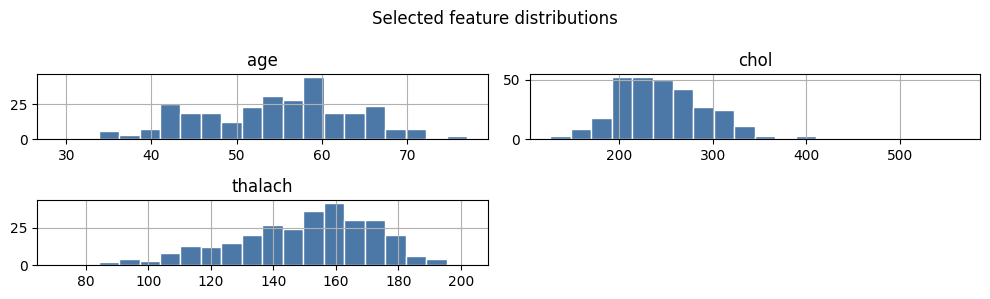

In [4]:
columns_to_plot = [column for column in ["age", "chol", "thalach"] if column in df.columns]
if not columns_to_plot:
    print("No standard numeric columns found; inspect the summary table above.")
else:
    axes = df[columns_to_plot].hist(bins=20, figsize=(10, 3), color="#4C78A8", edgecolor="white")
    plt.suptitle("Selected feature distributions")
    plt.tight_layout()
    plt.show()
